### Imports


In [ ]:
!pip install -U "bitsandbytes>=0.46.1" "accelerate" "transformers" "sentencepiece" "safetensors"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 148.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import os
import re
import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

## Model and Tokenizer loading

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    quantization_config=quant_config,
    trust_remote_code=True,
)

model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-3B-Instruct


### System prompt

In [ ]:
SYSTEM_PROMPT = (
    "You are a multiple-choice question answering system. "
    "Read the question and options carefully. "
    "Return only the final answer label (e.g., A, B, C, D, or E). "
    "Do not explain your reasoning."
)

def build_messages(question: str, options: dict) -> list:
    option_lines = []
    for label, text in options.items():
        option_lines.append(f"{label}. {text}")
    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        f"Answer with only the label."
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

def build_prompt_text(question: str, options: dict) -> str:
    messages = build_messages(question, options)
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

### Helpers for scoring and parsing

In [ ]:
import re
import torch
import torch.nn.functional as F

def normalize_label(text: str) -> str:
    text = str(text).strip().upper()
    match = re.search(r"\b([A-Z])\b", text)
    if match:
        return match.group(1)
    if len(text) > 0 and text[0].isalpha():
        return text[0]
    return text

def build_system_prompt(valid_labels) -> str:
    label_list = ", ".join(valid_labels)
    return (
        "You are a multiple-choice question answering system. "
        "Read the question and options carefully. "
        f"Return only the final answer label, one of {label_list}. "
        "Do not explain your reasoning."
    )

def build_messages(question: str, options: dict) -> list:
    option_lines = [f"{label}. {text}" for label, text in options.items()]
    valid_labels = list(options.keys())

    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Options:\n" + "\n".join(option_lines) + "\n\n"
        f"Answer with only the label."
    )

    return [
        {"role": "system", "content": build_system_prompt(valid_labels)},
        {"role": "user", "content": user_prompt},
    ]

def build_prompt_text(question: str, options: dict) -> str:
    messages = build_messages(question, options)
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

def get_label_token_ids(label: str):
    """
    Returns token ids for a label using both 'A' and ' A' forms when possible.
    Keeps only single-token encodings.
    """
    candidates = [label, f" {label}"]
    token_ids = []

    for cand in candidates:
        ids = tokenizer(cand, add_special_tokens=False)["input_ids"]
        if len(ids) == 1:
            token_ids.append(ids[0])

    token_ids = list(dict.fromkeys(token_ids))
    if len(token_ids) == 0:
        raise ValueError(f"Label {label} is not a single token in this tokenizer.")
    return token_ids

def generate_answer_and_logs(question: str, options: dict, topk: int = 10) -> dict:
    """
    Runs baseline generation and collects uncertainty-related signals.
    Uses one generation step only, then scores labels from the next-token logits.
    """
    option_labels = list(options.keys())
    prompt_text = build_prompt_text(question, options)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        gen_out = model.generate(
            **inputs,
            max_new_tokens=1,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    seq = gen_out.sequences[0]
    generated_ids = seq[prompt_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    generated_label = normalize_label(generated_text)

    step_logs = []
    chosen_token_logprobs = []
    chosen_token_strings = []

    if len(gen_out.scores) > 0:
        step_scores = gen_out.scores[0][0]  # logits for the first generated token
        probs = torch.softmax(step_scores, dim=-1)
        log_probs = torch.log_softmax(step_scores, dim=-1)

        token_id = generated_ids[0].item() if len(generated_ids) > 0 else None
        token_text = tokenizer.decode([token_id], skip_special_tokens=True) if token_id is not None else ""

        chosen_lp = float(log_probs[token_id].item()) if token_id is not None else None
        chosen_prob = float(probs[token_id].item()) if token_id is not None else None
        entropy_vocab = float(-(probs * torch.log(probs + 1e-12)).sum().item())

        top_probs, top_ids = torch.topk(probs, k=min(topk, probs.shape[0]))
        topk_tokens = []
        for p, tid in zip(top_probs.tolist(), top_ids.tolist()):
            topk_tokens.append({
                "token_id": tid,
                "token_text": tokenizer.decode([tid], skip_special_tokens=True),
                "prob": float(p),
                "logprob": float(log_probs[tid].item()),
            })

        step_logs.append({
            "step": 0,
            "chosen_token_id": token_id,
            "chosen_token_text": token_text,
            "chosen_token_logprob": chosen_lp,
            "chosen_token_prob": chosen_prob,
            "entropy_over_vocab": entropy_vocab,
            "topk": topk_tokens,
        })

        if token_id is not None:
            chosen_token_logprobs.append(chosen_lp)
            chosen_token_strings.append(token_text)

    # Score candidate labels from the first-step logits
    step_scores = gen_out.scores[0][0]
    step_log_probs = torch.log_softmax(step_scores, dim=-1)

    label_scores = {}
    label_details = {}

    for label in option_labels:
        cand_ids = get_label_token_ids(label)
        cand_logprobs = torch.tensor([step_log_probs[tok_id].item() for tok_id in cand_ids], dtype=torch.float32)

        # Combine alternative single-token encodings, if both exist
        label_logprob = torch.logsumexp(cand_logprobs, dim=0).item()

        label_scores[label] = label_logprob
        label_details[label] = {
            "candidate_token_ids": cand_ids,
            "candidate_token_logprobs": [float(step_log_probs[tok_id].item()) for tok_id in cand_ids],
            "label_logprob": float(label_logprob),
        }

    labels = list(label_scores.keys())
    label_logprob_tensor = torch.tensor([label_scores[l] for l in labels], dtype=torch.float32)
    label_probs = torch.softmax(label_logprob_tensor, dim=0)

    label_prob_dict = {label: float(label_probs[i].item()) for i, label in enumerate(labels)}
    sorted_labels = sorted(label_prob_dict.items(), key=lambda x: x[1], reverse=True)

    top1_label, top1_prob = sorted_labels[0]
    top2_label, top2_prob = sorted_labels[1] if len(sorted_labels) > 1 else (None, None)
    margin = float(top1_prob - top2_prob) if top2_prob is not None else None
    entropy_labels = float(-(label_probs * torch.log(label_probs + 1e-12)).sum().item())

    return {
        "prompt_text": prompt_text,
        "generated_text": generated_text,
        "generated_label": generated_label,
        "generated_token_ids": generated_ids.tolist(),
        "generated_token_texts": chosen_token_strings,
        "generated_token_logprobs": chosen_token_logprobs,
        "step_logs": step_logs,
        "label_scores": label_scores,
        "label_details": label_details,
        "label_probs": label_prob_dict,
        "predicted_label_by_label_probs": top1_label,
        "top1_prob": top1_prob,
        "top2_label": top2_label,
        "top2_prob": top2_prob,
        "margin": margin,
        "entropy_over_labels": entropy_labels,
    }

### Load Dataset

In [ ]:
df = pd.read_csv("/content/combined_dataset.csv")

import ast

df["choice_labels"] = df["choice_labels"].apply(ast.literal_eval)
df["choice_texts"] = df["choice_texts"].apply(ast.literal_eval)

print(df.head(2))
print(df.columns)

  source task_type source_id  \
0   MMLU       mcq       NaN   
1   MMLU       mcq       NaN   

                                            question context choice_labels  \
0  Long ago ,there lived in Greece a learned man....     NaN  [A, B, C, D]   
1  It is found that American students spend less ...     NaN  [A, B, C, D]   

                                        choice_texts gold_label  gold_index  \
0         [kindness, knowledge, patience, questions]          B           1   
1  [parental involvement makes up for what school...          D           3   

                                           gold_text explanation  subject meta  
0                                          knowledge         NaN      NaN   {}  
1  students may well make greater achievements wi...         NaN      NaN   {}  
Index(['source', 'task_type', 'source_id', 'question', 'context',
       'choice_labels', 'choice_texts', 'gold_label', 'gold_index',
       'gold_text', 'explanation', 'subject', 'meta']

### Trial Run

In [ ]:
def predict_and_log(question: str, options: dict, topk: int = 10) -> dict:
    option_labels = list(options.keys())
    prompt_text = build_prompt_text(question, options)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1]   # next-token logits after the prompt

    probs_vocab = torch.softmax(logits, dim=-1)
    log_probs_vocab = torch.log_softmax(logits, dim=-1)

    # For debugging, top-k next tokens
    top_probs, top_ids = torch.topk(probs_vocab, k=min(topk, probs_vocab.shape[0]))
    topk_tokens = []
    for p, tid in zip(top_probs.tolist(), top_ids.tolist()):
        topk_tokens.append({
            "token_id": tid,
            "token_text": tokenizer.decode([tid], skip_special_tokens=True),
            "prob": float(p),
            "logprob": float(log_probs_vocab[tid].item()),
        })

    # Score labels directly from the next-token distribution
    label_scores = {}
    label_details = {}

    for label in option_labels:
        cand_ids = tokenizer(label, add_special_tokens=False)["input_ids"]
        if len(cand_ids) != 1:
            raise ValueError(f"Label {label} is not a single token in this tokenizer.")
        tok_id = cand_ids[0]
        label_scores[label] = float(log_probs_vocab[tok_id].item())
        label_details[label] = {
            "token_id": tok_id,
            "token_text": tokenizer.decode([tok_id], skip_special_tokens=True),
            "token_logprob": float(log_probs_vocab[tok_id].item()),
            "token_prob": float(probs_vocab[tok_id].item()),
        }

    labels = list(label_scores.keys())
    score_tensor = torch.tensor([label_scores[l] for l in labels], dtype=torch.float32)
    label_probs = torch.softmax(score_tensor, dim=0)

    label_prob_dict = {label: float(label_probs[i].item()) for i, label in enumerate(labels)}
    sorted_labels = sorted(label_prob_dict.items(), key=lambda x: x[1], reverse=True)

    top1_label, top1_prob = sorted_labels[0]
    top2_label, top2_prob = sorted_labels[1] if len(sorted_labels) > 1 else (None, None)
    margin = float(top1_prob - top2_prob) if top2_prob is not None else None
    entropy_labels = float(-(label_probs * torch.log(label_probs + 1e-12)).sum().item())

    # Optional, if you want the model's actual greedy answer
    generated_label = top1_label

    return {
        "prompt_text": prompt_text,
        "generated_text": generated_label,
        "generated_label": generated_label,
        "label_scores": label_scores,
        "label_details": label_details,
        "label_probs": label_prob_dict,
        "predicted_label_by_label_probs": top1_label,
        "top1_prob": top1_prob,
        "top2_label": top2_label,
        "top2_prob": top2_prob,
        "margin": margin,
        "entropy_over_labels": entropy_labels,
        "topk": topk_tokens,
    }

In [ ]:
row = df.iloc[0]

question = row["question"]
options = dict(zip(row["choice_labels"], row["choice_texts"]))
gold = row["choice_labels"]

result = predict_and_log(question, options)

print("Gold:", gold)
print("Generated text:", result["generated_text"])
print("Generated label:", result["generated_label"])
print("Predicted label by option probs:", result["predicted_label_by_label_probs"])
print("Label probs:", result["label_probs"])
print("Entropy over labels:", result["entropy_over_labels"])
print("Margin:", result["margin"])

Gold: ['A', 'B', 'C', 'D']
Generated text: B
Generated label: B
Predicted label by option probs: B
Label probs: {'A': 0.005090922582894564, 'B': 0.9826730489730835, 'C': 0.0014585737371817231, 'D': 0.010777483694255352}
Entropy over labels: 0.10240765661001205
Margin: 0.9718955652788281


### Run full baseline and save outputs

In [ ]:
from tqdm import tqdm

output_dir = Path("qwen_baseline_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

jsonl_path = output_dir / "baseline_detailed.jsonl"
csv_path = output_dir / "baseline_summary.csv"

detailed_rows = []
summary_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    if idx % 50 == 0:
      print(f"Processed {idx}")
    question = row["question"]
    options = dict(zip(row["choice_labels"], row["choice_texts"]))

    gold = normalize_label(str(row["choice_labels"]))

    out = generate_answer_and_logs(question, options)
    pred = normalize_label(out["generated_label"])
    pred_by_probs = normalize_label(out["predicted_label_by_label_probs"])

    correct_generated = int(pred == gold)
    correct_by_probs = int(pred_by_probs == gold)

    detailed_record = {
        "row_id": int(idx),
        "gold_label": gold,
        "generated_label": pred,
        "generated_text": out["generated_text"],
        "predicted_label_by_probs": pred_by_probs,
        "top1_prob": out["top1_prob"],
        "top2_label": out["top2_label"],
        "top2_prob": out["top2_prob"],
        "margin": out["margin"],
        "entropy_over_labels": out["entropy_over_labels"],
        "label_probs": out["label_probs"],
        "label_scores": out["label_scores"],
        "generated_token_ids": out["generated_token_ids"],
        "generated_token_texts": out["generated_token_texts"],
        "generated_token_logprobs": out["generated_token_logprobs"],
        "step_logs": out["step_logs"],
        "correct_generated": correct_generated,
        "correct_by_probs": correct_by_probs,
    }
    detailed_rows.append(detailed_record)

    summary_rows.append({
        "row_id": int(idx),
        "gold_label": gold,
        "generated_label": pred,
        "predicted_label_by_probs": pred_by_probs,
        "correct_generated": correct_generated,
        "correct_by_probs": correct_by_probs,
        "top1_prob": out["top1_prob"],
        "margin": out["margin"],
        "entropy_over_labels": out["entropy_over_labels"],
    })

    with open(jsonl_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(detailed_record, ensure_ascii=False) + "\n")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(csv_path, index=False)

print("Saved detailed JSONL to:", jsonl_path)
print("Saved summary CSV to:", csv_path)
print(summary_df.head())

  0%|          | 0/1500 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processed 0


  3%|▎         | 51/1500 [00:07<03:16,  7.39it/s]

Processed 50


  7%|▋         | 101/1500 [00:13<03:07,  7.47it/s]

...

Processed 1400


 97%|█████████▋| 1451/1500 [03:11<00:06,  7.68it/s]

Processed 1450


100%|██████████| 1500/1500 [03:18<00:00,  7.57it/s]

Saved detailed JSONL to: qwen_baseline_outputs/baseline_detailed.jsonl
Saved summary CSV to: qwen_baseline_outputs/baseline_summary.csv
   row_id gold_label generated_label predicted_label_by_probs  \
0       0          A               B                        B   
1       1          A               A                        A   
2       2          A               A                        A   
3       3          A               D                        D   
4       4          A               D                        D   

   correct_generated  correct_by_probs  top1_prob    margin  \
0                  0                 0   0.977947  0.964486   
1                  1                 1   0.766824  0.533652   
2                  1                 1   0.991511  0.983034   
3                  0                 0   1.000000  1.000000   
4                  0                 0   0.999998  0.999996   

   entropy_over_labels  
0         1.253373e-01  
1         5.431234e-01  
2         4.904118e

### Quick aggregate check

In [ ]:
print("Accuracy using generated label:", summary_df["correct_generated"].mean())
print("Accuracy using option-prob argmax:", summary_df["correct_by_probs"].mean())
print("Mean margin:", summary_df["margin"].mean())
print("Mean entropy:", summary_df["entropy_over_labels"].mean())

wrong = summary_df[summary_df["correct_by_probs"] == 0]
right = summary_df[summary_df["correct_by_probs"] == 1]

print("Avg margin, correct:", right["margin"].mean())
print("Avg margin, wrong:", wrong["margin"].mean())
print("Avg entropy, correct:", right["entropy_over_labels"].mean())
print("Avg entropy, wrong:", wrong["entropy_over_labels"].mean())

Accuracy using generated label: 0.3233333333333333
Accuracy using option-prob argmax: 0.3233333333333333
Mean margin: 0.9224834561034183
Mean entropy: 0.10670164080739847
Avg margin, correct: 0.9505653400980004
Avg margin, wrong: 0.909065018923741
Avg entropy, correct: 0.06503006220193844
Avg entropy, wrong: 0.1266136759045887


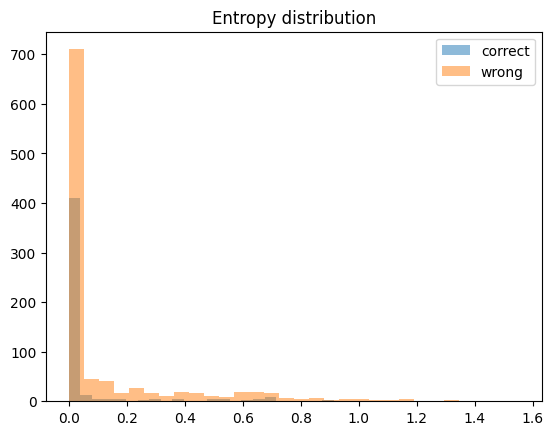

In [ ]:
import matplotlib.pyplot as plt

plt.hist(summary_df[summary_df["correct_by_probs"] == 1]["entropy_over_labels"], bins=30, alpha=0.5, label="correct")
plt.hist(summary_df[summary_df["correct_by_probs"] == 0]["entropy_over_labels"], bins=30, alpha=0.5, label="wrong")
plt.legend()
plt.title("Entropy distribution")
plt.show()